# 13 - Overlay: theme conviction vs ETF price (AUTO, weekly)

Auto-picks the highest-sentiment themes and overlays each theme's conviction_z
against its ETF's price. `FREQ='W'` averages conviction weekly for a smoother
read.

In [1]:
import os, sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
P = os.path.join(ROOT, 'data', 'processed')
PRICES_PATH = os.path.join(ROOT, 'data', 'prices', 'prices.parquet')

# window: the PIPELINE_* env vars (set by update_data.py, including its
# --start/--end overrides) win; otherwise fall back to the constants at the
# top of update_data.py. Same toggle as live vs backtest either way.
import update_data
START_DATE = os.environ.get('PIPELINE_START_DATE') or update_data.START_DATE
END_DATE = os.environ.get('PIPELINE_END_DATE')
if END_DATE is None:
    END_DATE = update_data.END_DATE
WIN_LO = pd.to_datetime(START_DATE)
WIN_HI = pd.to_datetime(END_DATE) if END_DATE else None
print('window:', WIN_LO.date(), '->', (WIN_HI.date() if WIN_HI is not None else 'LIVE (newest)'))

def clip_series(s):
    s = s[s.index >= WIN_LO]
    return s if WIN_HI is None else s[s.index <= WIN_HI]

def clip_dates(df, col):
    df = df[df[col] >= WIN_LO]
    return df if WIN_HI is None else df[df[col] <= WIN_HI]

def load_prices():
    if not os.path.exists(PRICES_PATH):
        raise FileNotFoundError('prices.parquet not found - run  python pull_bloomberg_prices.py  first.')
    px = pd.read_parquet(PRICES_PATH); px['date'] = pd.to_datetime(px['date'])
    return px

def price_series(prices, symbol):
    # daily close, then made CONTINUOUS (forward-fill weekends/holidays) so the
    # line is smooth with no gaps. Clip to the window.
    one = prices[prices['symbol'] == symbol].sort_values('date')
    s = one.set_index('date')['px_last']
    if not s.empty:
        s = s.asfreq('D').ffill()
    return clip_series(s)


# --- x-axis tick control (X_TICKS in the parameters cell) ---
# 'auto' = matplotlib decides; 'W' = a label every week; 'M' = every month.
# Weekly labels are only readable on windows up to ~6 months - use
# PLOT_LAST_DAYS to zoom in first.
import matplotlib.dates as mdates

def set_date_ticks(ax, ticks):
    if ticks == 'W':
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Mondays
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
    elif ticks == 'M':
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

window: 2026-01-08 -> 2026-06-08


In [2]:
from src.themes import THEME_ETFS
HOW_MANY = 6
FREQ = 'W'        # 'W' weekly, 'D' daily, 'M' monthly
MIN_POSTS = 30    # ignore barely-discussed themes when ranking sentiment
X_TICKS = 'auto'  # x-axis labels: 'auto', 'W' (weekly), 'M' (monthly)
PLOT_LAST_DAYS = None   # e.g. 120 = zoom to the last 120 days (None = whole window)

auto themes (highest sentiment): ['cannabis', 'small_caps', 'solar', 'infrastructure', 'europe_defense', 'datacenters']


skip cannabis - no ETF
skip small_caps - no ETF


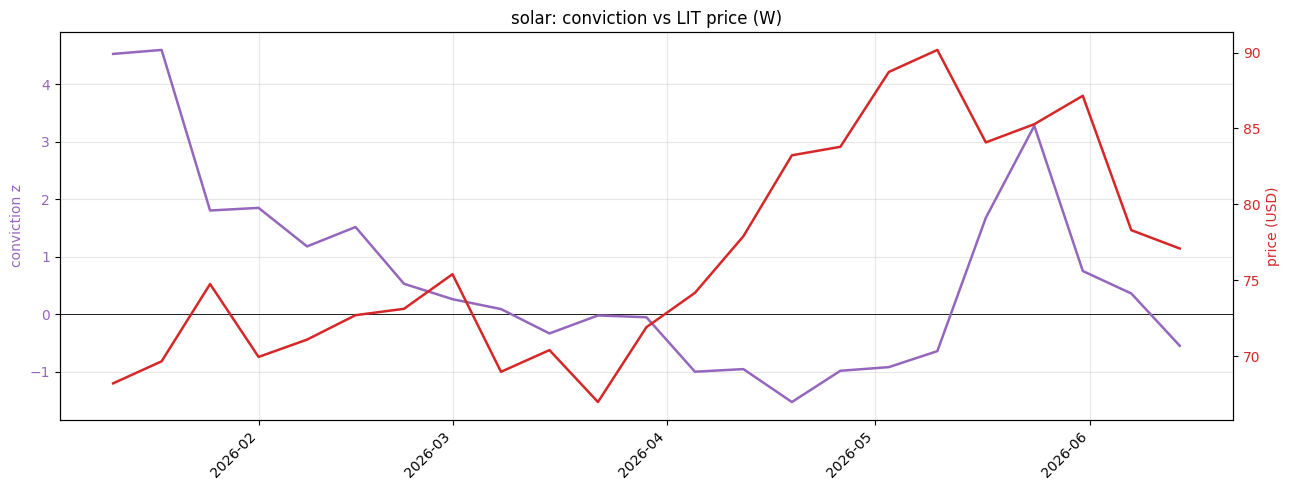

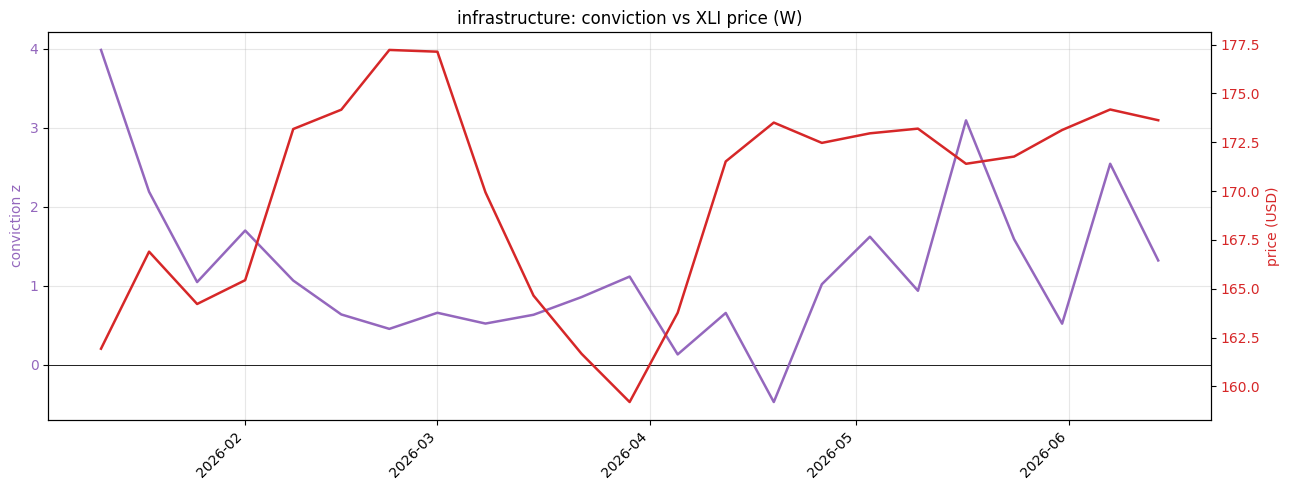

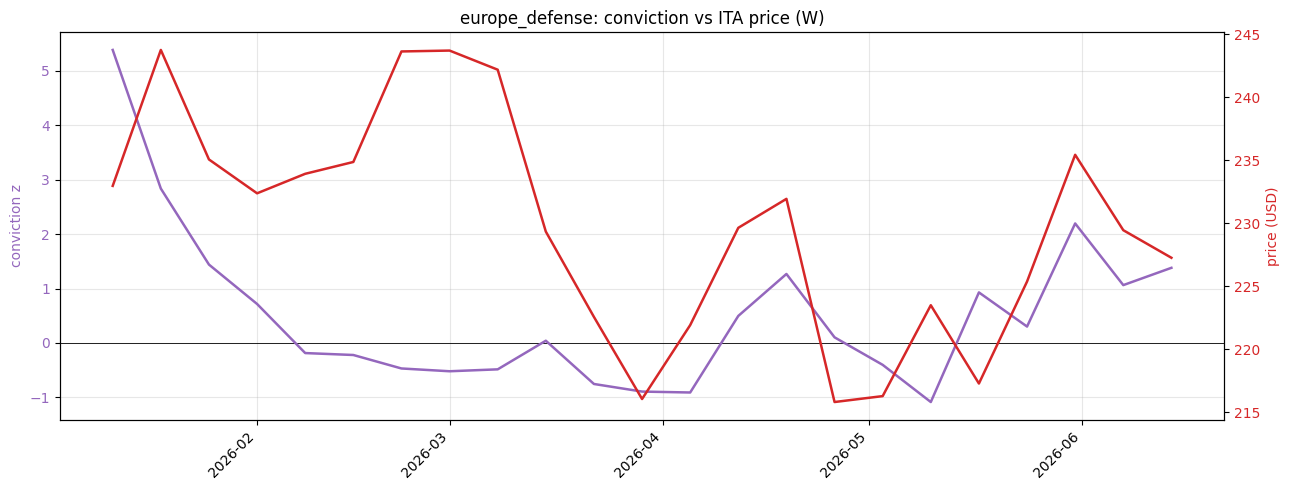

note datacenters - VPN has no price data at all in prices.parquet - re-run pull_bloomberg_prices.py


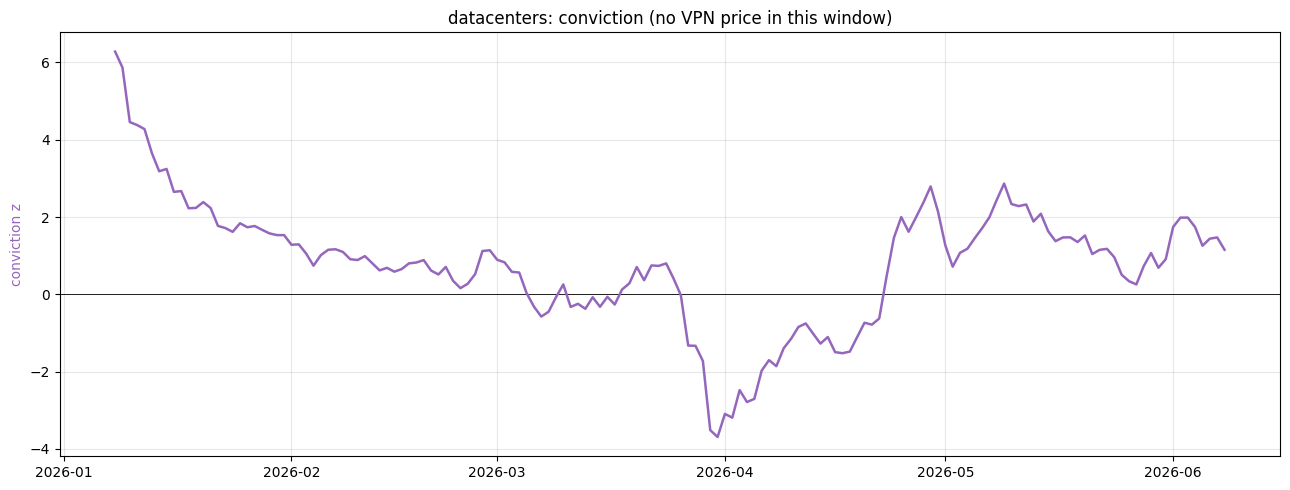

In [3]:
tsent = pd.read_parquet(os.path.join(P, 'daily_theme_sentiment.parquet'))
tsent['date'] = pd.to_datetime(tsent['date']); tsent = clip_dates(tsent, 'date')
if tsent.empty:
    print('!' * 72)
    print(f'NO AGGREGATE DATA in this window ({START_DATE} -> {END_DATE or "today"}).')
    print("Fix: run  python update_data.py --full  once (builds the aggregates")
    print('over ALL history); see the WINDOW CHECK in the run log for detail.')
    print('!' * 72)
posts = tsent.groupby('theme')['n_posts'].sum(); mood = tsent.groupby('theme')['net_bullish'].mean()
themes = mood[posts >= MIN_POSTS].sort_values(ascending=False).head(HOW_MANY).index.tolist()
print('auto themes (highest sentiment):', themes)
conv = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv['date'] = pd.to_datetime(conv['date'])
if PLOT_LAST_DAYS:                       # zoom: only the most recent stretch
    WIN_LO = max(WIN_LO, conv['date'].max() - pd.Timedelta(days=PLOT_LAST_DAYS))
prices = load_prices()

for theme in themes:
    etf = THEME_ETFS.get(theme)
    if etf is None: print('skip', theme, '- no ETF'); continue
    c = clip_series(conv[conv['theme'] == theme].sort_values('date').set_index('date')['conviction_z'])
    px = price_series(prices, etf)
    # Young ETFs have no data early in the window (IBIT starts Jan-2024,
    # MAGS Apr-2023...). We do NOT substitute another instrument - we plot
    # whatever price history exists and mark where it begins.
    all_px = prices[prices['symbol'] == etf]
    price_starts = all_px['date'].min() if len(all_px) else None
    if px.empty:
        if price_starts is None:
            print('note', theme, f'- {etf} has no price data at all in prices.parquet '
                  '- re-run pull_bloomberg_prices.py')
        else:
            print('note', theme, f'- {etf} price data only starts {price_starts.date()} '
                  '(after this window) - plotting conviction alone')
        fig, ax1 = plt.subplots(figsize=(13, 5))
        ax1.axhline(0, color='black', linewidth=0.6)
        ax1.plot(c.index, c.values, color='tab:purple', linewidth=1.8)
        ax1.set_ylabel('conviction z', color='tab:purple')
        note = f'no {etf} price in this window' + (f' ({etf} starts {price_starts.date()})' if price_starts is not None else '')
        ax1.set_title(f'{theme}: conviction (' + note + ')')
        ax1.grid(True, alpha=0.3); fig.tight_layout(); plt.show()
        continue
    price_gap = price_starts is not None and (px.index.min() - WIN_LO).days > 7
    if price_gap:
        print('note', theme, f'- {etf} price data only starts {px.index.min().date()}')
    if FREQ != 'D':
        c = c.resample(FREQ).mean(); px = px.resample(FREQ).last()
    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.axhline(0, color='black', linewidth=0.6)
    ax1.plot(c.index, c.values, color='tab:purple', linewidth=1.8, label='conviction_z')
    ax1.set_ylabel('conviction z', color='tab:purple'); ax1.tick_params(axis='y', labelcolor='tab:purple')
    ax2 = ax1.twinx(); ax2.plot(px.index, px.values, color='tab:red', linewidth=1.8, label='price')
    ax2.set_ylabel('price (USD)', color='tab:red'); ax2.tick_params(axis='y', labelcolor='tab:red')
    if price_gap:
        ax1.axvline(px.index.min(), color='gray', linestyle='--', linewidth=1)
        ax1.annotate(f'{etf} price data starts', (px.index.min(), ax1.get_ylim()[1]),
                     fontsize=8, ha='left', va='top', color='gray')
    ax1.set_title(f'{theme}: conviction vs {etf} price ({FREQ})'); ax1.grid(True, alpha=0.3)
    set_date_ticks(ax1, X_TICKS)
    fig.tight_layout(); plt.show()

## Does conviction LEAD price? (lead/lag scan)

For every plotted theme: correlate conviction_z today with the anchor ETF's
daily move k days away, k = -MAX_LAG..+MAX_LAG.

- **Peak RIGHT of zero** → conviction today predicts price moves k days
  later: conviction builds BEFORE the move (the tradeable case, and the
  delay to use when acting on notebook 10's signals).
- **Peak LEFT of zero** → price moves first, conviction follows: the crowd
  is reacting, not anticipating (chasing).
- Flat everywhere → conviction level carries no timing information for that
  theme; changes (velocity) may still work where levels do not.

The second panel groups all theme-days into conviction quintiles and shows
the average forward move - the level-based version of the same question.

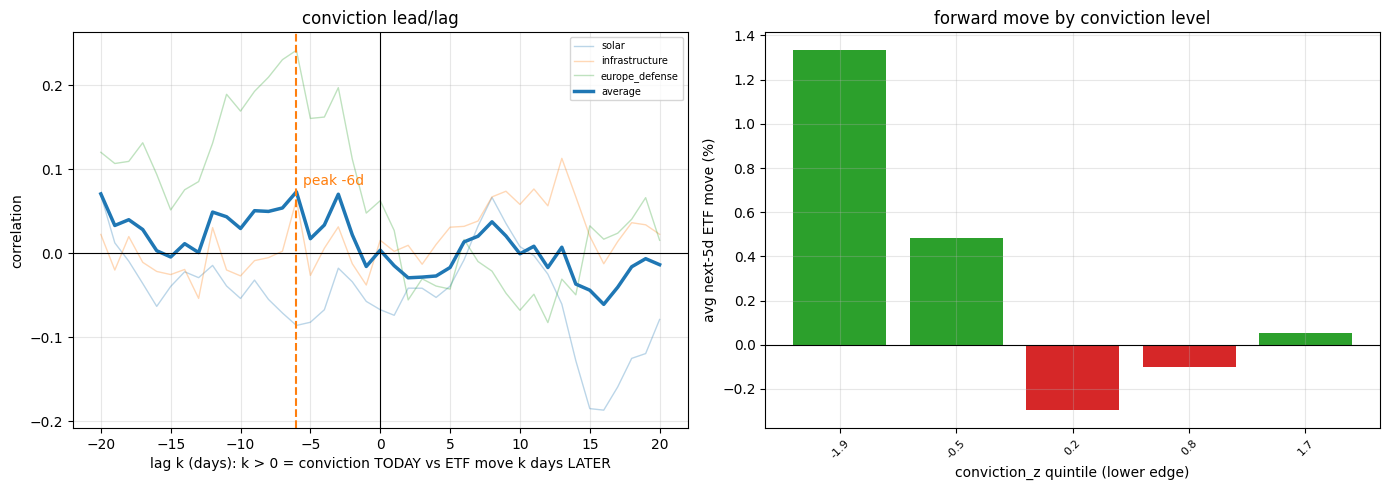

lead/lag verdict: correlation peaks at -6 days -> the ETF moves first; conviction follows (chasing)


In [4]:
# ==== CONVICTION LEAD/LAG vs anchor ETF price ====
MAX_LAG  = 20   # scan -MAX_LAG..+MAX_LAG days
FWD_DAYS = 5    # forward-move horizon for the quintile panel

conv_ll = pd.read_parquet(os.path.join(P, 'daily_theme_conviction.parquet'))
conv_ll['date'] = pd.to_datetime(conv_ll['date']); conv_ll = clip_dates(conv_ll, 'date')
prices_ll = load_prices()
priced_ll = set(prices_ll['symbol'])

lags = list(range(-MAX_LAG, MAX_LAG + 1))
curves, pairs = {}, []
for theme_name in themes:                      # the same themes plotted above
    etf = THEME_ETFS.get(theme_name)
    if etf not in priced_ll:
        continue
    one = prices_ll[prices_ll['symbol'] == etf].sort_values('date')
    px = one.set_index('date')['px_last'].asfreq('D').ffill()
    cz = (conv_ll[conv_ll['theme'] == theme_name].sort_values('date')
          .set_index('date')['conviction_z'].asfreq('D').ffill())
    dr = px.pct_change() * 100
    curves[theme_name] = [cz.corr(dr.shift(-k)) for k in lags]
    fwd = (px.shift(-FWD_DAYS) / px - 1) * 100
    both = pd.DataFrame({'conv': cz, 'fwd_ret': fwd}).dropna()
    both['theme'] = theme_name
    pairs.append(both)

if curves:
    mean_curve = pd.DataFrame(curves, index=lags).mean(axis=1)
    best_lag = int(mean_curve.idxmax()) if mean_curve.notna().any() else 0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for nm, c in curves.items():
        ax1.plot(lags, c, alpha=0.3, linewidth=1, label=nm)
    ax1.plot(lags, mean_curve.values, linewidth=2.5, color='tab:blue', label='average')
    ax1.axvline(0, color='black', linewidth=0.8); ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axvline(best_lag, color='tab:orange', linestyle='--')
    ax1.annotate(f'peak {best_lag:+d}d', (best_lag, mean_curve.max()),
                 textcoords='offset points', xytext=(5, 5), color='tab:orange')
    ax1.set_xlabel('lag k (days): k > 0 = conviction TODAY vs ETF move k days LATER')
    ax1.set_ylabel('correlation'); ax1.set_title('conviction lead/lag')
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

    pairs = pd.concat(pairs)
    bins = pd.qcut(pairs['conv'], 5, duplicates='drop')
    summary = pairs.groupby(bins, observed=True)['fwd_ret'].agg(['mean', 'count'])
    ax2.bar(range(len(summary)), summary['mean'],
            color=['tab:red' if v < 0 else 'tab:green' for v in summary['mean']])
    ax2.set_xticks(range(len(summary)))
    ax2.set_xticklabels([f'{iv.left:.1f}' for iv in summary.index], rotation=45, fontsize=8)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('conviction_z quintile (lower edge)')
    ax2.set_ylabel(f'avg next-{FWD_DAYS}d ETF move (%)')
    ax2.set_title('forward move by conviction level'); ax2.grid(True, alpha=0.3)
    fig.tight_layout(); plt.show()

    print(f'lead/lag verdict: correlation peaks at {best_lag:+d} days '
          + ('-> conviction LEADS the ETF (act with that delay)' if best_lag > 0 else
         '-> the ETF moves first; conviction follows (chasing)'))
else:
    print('no themes with priced anchors in this window')

## Evidence view: chatter DIRECTION FLIPS marked on the price chart

No transformations - the price line is untouched. A green up-triangle marks
the day the smoothed chatter change TURNS POSITIVE (crowd re-engaging), a
red down-triangle the day it TURNS NEGATIVE (crowd losing interest). The
shading covers the measured lead window after each flip; the title compares
the average price move after each direction against the baseline drift.
**If green flips sit in front of rallies and red flips in front of fades,
attention direction leads price direction** - visible at a glance.

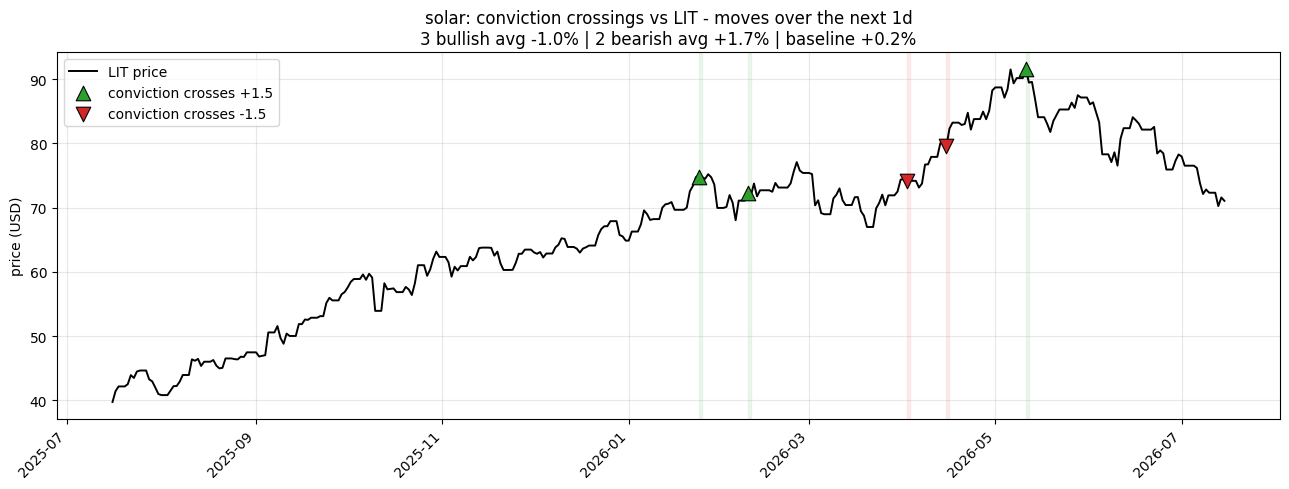

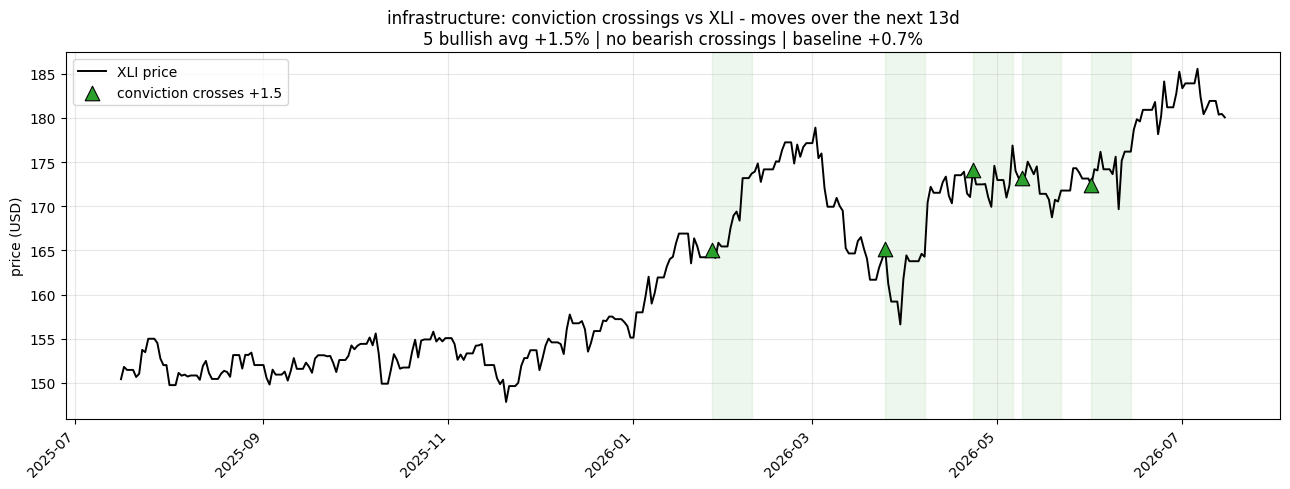

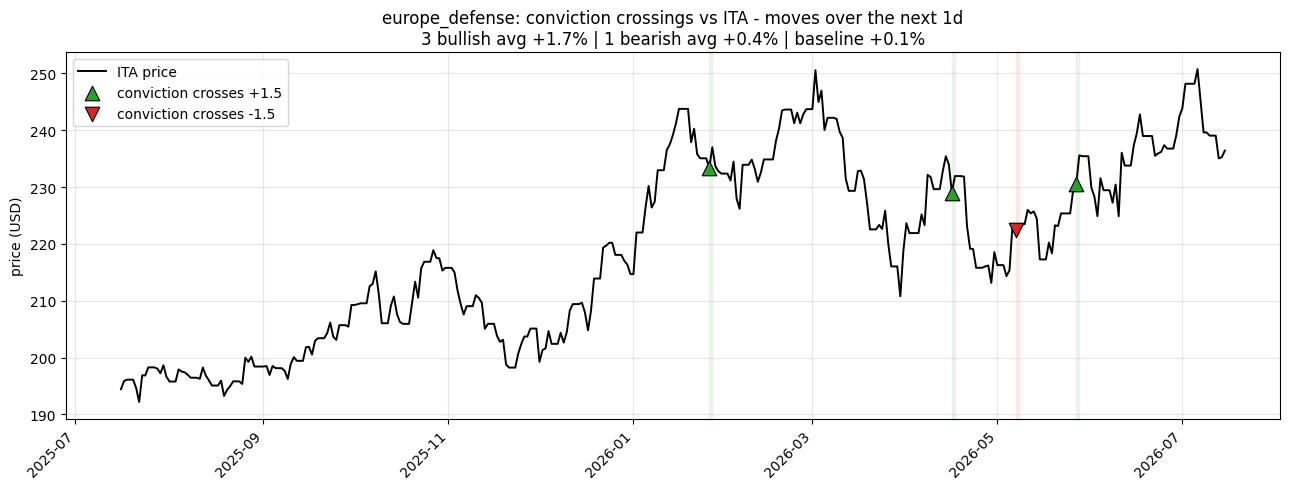

In [5]:
# ==== SPIKE EVIDENCE v2 - DIRECTION FLIPS (conviction): crossings on ETF price ====
SHOW_N   = 3
CROSS_AT = 1.5    # an event = conviction_z crossing +CROSS_AT (bullish) or
MIN_GAP  = 10     # -CROSS_AT (bearish); days between counted events
if curves:
    for theme_name in list(curves)[:SHOW_N]:
        c = pd.Series(curves[theme_name], index=lags)
        k = max(int(c.idxmax()), 1) if c.notna().any() else 1
        etf = THEME_ETFS.get(theme_name)
        one = prices_ll[prices_ll['symbol'] == etf].sort_values('date')
        px = one.set_index('date')['px_last'].asfreq('D').ffill()
        cz = (conv_ll[conv_ll['theme'] == theme_name].sort_values('date')
              .set_index('date')['conviction_z'].asfreq('D').ffill())

        def spaced(idx, gap):
            out = []
            for d in idx:
                if not out or (d - out[-1]).days >= gap:
                    out.append(d)
            return out
        up = spaced(cz[(cz > CROSS_AT) & (cz.shift(1) <= CROSS_AT)].index, MIN_GAP)
        down = spaced(cz[(cz < -CROSS_AT) & (cz.shift(1) >= -CROSS_AT)].index, MIN_GAP)

        def fwd_moves(events):
            out = []
            for d in events:
                p0 = px.asof(d); p1 = px.asof(d + pd.Timedelta(days=k))
                if pd.notna(p0) and pd.notna(p1) and p0 != 0:
                    out.append((p1 / p0 - 1) * 100)
            return out
        up_mv, dn_mv = fwd_moves(up), fwd_moves(down)
        baseline = ((px.shift(-k) / px - 1) * 100).mean()
        if not up_mv and not dn_mv:
            print(f'{theme_name}: no scoreable conviction crossings in this window')
            continue

        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(px.index, px.values, color='black', linewidth=1.4, label=f'{etf} price')
        for i, d in enumerate(up):
            ax.axvspan(d, d + pd.Timedelta(days=k), color='tab:green', alpha=0.08)
            pa = px.asof(d)
            if pd.notna(pa):
                ax.scatter([d], [pa], marker='^', s=110, color='tab:green',
                           edgecolors='black', linewidths=0.8, zorder=5,
                           label=f'conviction crosses +{CROSS_AT}' if i == 0 else None)
        for i, d in enumerate(down):
            ax.axvspan(d, d + pd.Timedelta(days=k), color='tab:red', alpha=0.08)
            pa = px.asof(d)
            if pd.notna(pa):
                ax.scatter([d], [pa], marker='v', s=110, color='tab:red',
                           edgecolors='black', linewidths=0.8, zorder=5,
                           label=f'conviction crosses -{CROSS_AT}' if i == 0 else None)
        up_s = (f'{len(up_mv)} bullish avg {sum(up_mv)/len(up_mv):+.1f}%'
                if up_mv else 'no bullish crossings')
        dn_s = (f'{len(dn_mv)} bearish avg {sum(dn_mv)/len(dn_mv):+.1f}%'
                if dn_mv else 'no bearish crossings')
        ax.set_title(f'{theme_name}: conviction crossings vs {etf} - moves over the next {k}d\n'
                     f'{up_s} | {dn_s} | baseline {baseline:+.1f}%')
        ax.set_ylabel('price (USD)')
        ax.legend(loc='upper left'); ax.grid(True, alpha=0.3)
        set_date_ticks(ax, X_TICKS)
        fig.tight_layout(); plt.show()